# S3 Vectors — Semantic Image Search with Amazon Nova Multimodal Embeddings

This notebook demonstrates **Amazon S3 Vectors**, AWS's native vector storage service, combined with **Amazon Nova Multimodal Embeddings** to build a semantic image search engine over the [Unsplash Lite dataset](https://unsplash.com/data).

**Pipeline**
1. Sample N random photos from the Unsplash dataset
2. Generate 1024-dimensional embeddings with **Nova Multimodal Embeddings** (Bedrock)
3. Store vectors in an **S3 Vector Index** (cosine similarity)
4. Pick a query image → retrieve the **5 most visually similar** photos

**AWS services**
| Service | Role |
|---|---|
| Amazon S3 Vectors | Native vector storage & ANN search |
| Amazon Bedrock | Nova Multimodal Embeddings (`amazon.nova-2-multimodal-embeddings-v1:0`) |


In [ ]:
# ================================================================
# CONFIGURATION — Tune these values before running the notebook
# ================================================================

# Number of images to embed and index
# ↳ Start with 100 for a quick demo (~3 min), scale to 1000 for the full run
NUM_IMAGES = 1000

# S3 Vectors infrastructure
VECTOR_BUCKET_NAME = "unsplash-demo-vectors-753978855"   # Must be globally unique
INDEX_NAME         = "photos-index"

# Amazon Nova Multimodal Embeddings model
EMBEDDING_MODEL_ID  = "amazon.nova-2-multimodal-embeddings-v1:0"
EMBEDDING_DIMENSION = 1024          # Options: 256 | 384 | 1024 | 3072

# AWS credentials
AWS_PROFILE = "pro"
AWS_REGION  = "us-east-1"

# Image download size (Unsplash CDN resize param — pixels)
# Smaller = faster downloads; larger = richer embeddings
IMAGE_DOWNLOAD_SIZE = 512

# Batch size for put_vectors API calls (max recommended: 100)
PUT_VECTORS_BATCH_SIZE = 100

# Similarity search — how many neighbours to retrieve
TOP_K = 5

# Reproducibility
RANDOM_SEED = 42


In [2]:
%pip install boto3 "pillow>=10" requests tqdm matplotlib pandas numpy --quiet


Note: you may need to restart the kernel to use updated packages.


In [2]:
import json, base64, io, random, time, glob, warnings

import boto3
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

%matplotlib inline
warnings.filterwarnings("ignore")
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Libraries loaded ✓")


Matplotlib is building the font cache; this may take a moment.


Libraries loaded ✓


---
## Step 1 — Load the Unsplash Dataset

The dataset folder contains the [Unsplash Lite dataset](https://unsplash.com/data): ~25 000 curated photos with metadata including CDN image URLs, AI descriptions, and photographer information.


In [3]:
path  = "./dataset/"
files = glob.glob(path + "photos.csv*")

photos_df = pd.concat(
    [pd.read_csv(f, sep="\t", header=0) for f in files],
    axis=0, ignore_index=True,
)

# Keep only rows that have a downloadable image URL
photos_df = photos_df.dropna(subset=["photo_image_url"]).reset_index(drop=True)

print(f"Total photos available: {len(photos_df):,}")
photos_df[["photo_id", "photo_image_url", "ai_description",
           "photographer_first_name", "photographer_last_name"]].head(3)


Total photos available: 25,000


,photo_id,photo_image_url,ai_description,photographer_first_name,photographer_last_name
0,oSf8ePoG9NU,https://images.unsplash.com/20/frozen-grass.JPG,black road in between white and brown grass ac...,Andre,Koch
1,DlsOa5moK4w,https://images.unsplash.com/reserve/dRA4UuMBR2...,selective focus of blueberry plant,Majk,M.
2,XBGacbT3vXI,https://images.unsplash.com/photo-143633523196...,photography of calm beach side,Shooshanig,Berumen


---
## Step 2 — Create AWS Clients

Two boto3 clients:
- **`bedrock-runtime`** — calls the Nova Multimodal Embeddings model
- **`s3vectors`** — manages vector buckets, indexes, and search


In [4]:
session = boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION)

bedrock_runtime = session.client("bedrock-runtime")
s3vectors_client = session.client("s3vectors")

# Verify credentials
identity = session.client("sts").get_caller_identity()
print(f"AWS Account : {identity['Account']}")
print(f"IAM Identity: {identity['Arn']}")
print(f"Region      : {AWS_REGION}")
print()
print("AWS clients ready ✓")


AWS Account : 1234567890
IAM Identity: arn:aws:iam::1234567890:user/your_user
Region      : us-east-1

AWS clients ready ✓


---
## Step 3 — Create S3 Vector Infrastructure

**S3 Vectors** introduces two primitives:

| Primitive | Description |
|---|---|
| **Vector Bucket** | Regional container (similar to an S3 bucket) |
| **Vector Index** | Named ANN index inside a bucket — defines dimension, type, and distance metric |

We configure **cosine** distance, which measures the angle between vectors (ideal for embeddings normalised to unit length).


In [7]:
# ---- Vector Bucket --------------------------------------------------------
print(f"Creating vector bucket: '{VECTOR_BUCKET_NAME}'")
try:
    s3vectors_client.create_vector_bucket(vectorBucketName=VECTOR_BUCKET_NAME)
    print("  ✓ Bucket created")
except s3vectors_client.exceptions.ConflictException:
    print("  ✓ Bucket already exists — skipping")

# ---- Vector Index ---------------------------------------------------------
print(f"\nCreating vector index: '{INDEX_NAME}'")
print(f"  Dimensions      : {EMBEDDING_DIMENSION}")
print(f"  Distance metric : cosine")
print(f"  Data type       : float32")

try:
    s3vectors_client.create_index(
        vectorBucketName=VECTOR_BUCKET_NAME,
        indexName=INDEX_NAME,
        dataType="float32",
        dimension=EMBEDDING_DIMENSION,
        distanceMetric="cosine",
    )
    print("  ✓ Index created")
except s3vectors_client.exceptions.ConflictException:
    print("  ✓ Index already exists — skipping")

print("\nS3 Vector infrastructure ready ✓")


Creating vector bucket: 'unsplash-demo-vectors-753978855'
  ✓ Bucket created

Creating vector index: 'photos-index'
  Dimensions      : 1024
  Distance metric : cosine
  Data type       : float32
  ✓ Index created

S3 Vector infrastructure ready ✓


---
## Step 4 — Generate Embeddings & Index Vectors

For each sampled photo we:
1. **Download** the image from Unsplash CDN (resized for speed)
2. **Generate** a 1024-dimensional embedding via Amazon Nova Multimodal Embeddings
3. **Batch-index** the vectors using `put_vectors`

> **Nova Multimodal Embeddings** (`amazon.nova-2-multimodal-embeddings-v1:0`) encodes text, images, video, and audio into a shared semantic space — enabling cross-modal retrieval.


In [8]:
def download_image(url: str, size: int = IMAGE_DOWNLOAD_SIZE) -> bytes:
    # Add Unsplash CDN resize params to limit bandwidth
    if "unsplash.com" in url and "?" not in url:
        url = f"{url}?w={size}&q=80&fit=max"
    resp = requests.get(url, timeout=20)
    resp.raise_for_status()
    return resp.content


def to_jpeg(raw: bytes) -> bytes:
    # Normalise any image format (PNG, WebP…) to JPEG for the embedding API
    img = Image.open(io.BytesIO(raw))
    buf = io.BytesIO()
    img.convert("RGB").save(buf, format="JPEG", quality=85, optimize=True)
    return buf.getvalue()


def generate_embedding(image_bytes: bytes) -> list:
    # 1. Convert to JPEG and base64-encode
    jpeg  = to_jpeg(image_bytes)
    b64   = base64.b64encode(jpeg).decode("utf-8")

    # 2. Build the Nova Multimodal Embeddings request body
    body  = {
        "taskType": "SINGLE_EMBEDDING",
        "singleEmbeddingParams": {
            "embeddingPurpose": "GENERIC_INDEX",
            "embeddingDimension": EMBEDDING_DIMENSION,
            "image": {
                "format": "jpeg",
                "source": {"bytes": b64},
            },
        },
    }

    # 3. Invoke the model via Bedrock Runtime
    resp  = bedrock_runtime.invoke_model(
        body=json.dumps(body),
        modelId=EMBEDDING_MODEL_ID,
        accept="application/json",
        contentType="application/json",
    )

    # 4. Extract the embedding vector from the response
    data  = json.loads(resp["body"].read())
    return data["embeddings"][0]["embedding"]


print("Helper functions defined ✓")
print(f"  Model     : {EMBEDDING_MODEL_ID}")
print(f"  Dimension : {EMBEDDING_DIMENSION}")


Helper functions defined ✓
  Model     : amazon.nova-2-multimodal-embeddings-v1:0
  Dimension : 1024


In [22]:
# Sample 
# AGES random photos
NUM_IMAGES=1000
sampled = photos_df.sample(n=NUM_IMAGES, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Sampled {NUM_IMAGES} photos from {len(photos_df):,} available")
print("Generating embeddings — this may take a few minutes...\n")

vectors = []   # list of dicts ready for put_vectors
errors  = []

for _, row in tqdm(sampled.iterrows(), total=NUM_IMAGES, desc="Embedding"):
    try:
        img_bytes = download_image(row["photo_image_url"])
        embedding = generate_embedding(img_bytes)

        vectors.append({
            "key" : row["photo_id"],
            "data": {"float32": embedding},
            "metadata": {
                "url"         : row["photo_image_url"],
                "description" : str(row.get("ai_description")         or ""),
                "photographer": (
                    str(row.get("photographer_first_name") or "") + " " +
                    str(row.get("photographer_last_name")  or "")
                ).strip(),
            },
        })
    except Exception as exc:
        errors.append({"id": row["photo_id"], "error": str(exc)})

print(f"\nEmbedding complete:")
print(f"  ✓ Succeeded : {len(vectors)}")
print(f"  ✗ Failed    : {len(errors)}")


Sampled 1000 photos from 25,000 available
Generating embeddings — this may take a few minutes...



Embedding: 100%|██████████| 1000/1000 [19:49<00:00,  1.19s/it]


Embedding complete:
  ✓ Succeeded : 1000
  ✗ Failed    : 0


In [23]:
# Store vectors in S3 Vectors with batched put_vectors calls
print(f"Indexing {len(vectors)} vectors into S3 Vectors...")

total_batches = -(-len(vectors) // PUT_VECTORS_BATCH_SIZE)   # ceiling division

for i in range(0, len(vectors), PUT_VECTORS_BATCH_SIZE):
    batch = vectors[i : i + PUT_VECTORS_BATCH_SIZE]

    s3vectors_client.put_vectors(
        vectorBucketName=VECTOR_BUCKET_NAME,
        indexName=INDEX_NAME,
        vectors=batch,
    )

    batch_num = i // PUT_VECTORS_BATCH_SIZE + 1
    print(f"  Batch {batch_num:2d}/{total_batches} — {len(batch)} vectors stored")

print(f"\nAll {len(vectors)} vectors indexed ✓")
print(f"  Bucket : {VECTOR_BUCKET_NAME}")
print(f"  Index  : {INDEX_NAME}")


Indexing 1000 vectors into S3 Vectors...
  Batch  1/10 — 100 vectors stored
  Batch  2/10 — 100 vectors stored
  Batch  3/10 — 100 vectors stored
  Batch  4/10 — 100 vectors stored
  Batch  5/10 — 100 vectors stored
  Batch  6/10 — 100 vectors stored
  Batch  7/10 — 100 vectors stored
  Batch  8/10 — 100 vectors stored
  Batch  9/10 — 100 vectors stored
  Batch 10/10 — 100 vectors stored

All 1000 vectors indexed ✓
  Bucket : unsplash-demo-vectors-753978855
  Index  : photos-index


---
## Step 5 — Semantic Image Search

We pick a **query image that was not indexed**, generate its embedding, and call `query_vectors` to find the 5 most visually similar photos in our S3 Vector Index.

S3 Vectors uses **Approximate Nearest Neighbour (ANN)** search — the query typically completes in single-digit milliseconds regardless of index size.


In [27]:
# Select a query image that is NOT in the indexed set
indexed_ids = {v["key"] for v in vectors}
query_pool  = photos_df[~photos_df["photo_id"].isin(indexed_ids)]
query_row   = query_pool.sample(1).iloc[0]

print("Query image (not in the index):")
print(f"  Photo ID    : {query_row['photo_id']}")
print(f"  Description : {query_row.get('ai_description', 'N/A')}")
print(f"  Photographer: {query_row.get('photographer_first_name', '')} "
      f"{query_row.get('photographer_last_name', '')}")
print(f"  URL         : {query_row['photo_image_url']}")

# Generate the query embedding
print("\nGenerating query embedding...")
query_bytes     = download_image(query_row["photo_image_url"])
query_embedding = generate_embedding(query_bytes)
print(f"Embedding ready — {len(query_embedding)} dimensions ✓")


Query image (not in the index):
  Photo ID    : PuobOOUjX5I
  Description : greyscale photo of an island under white clouds
  Photographer: Zurem Meru
  URL         : https://images.unsplash.com/photo-1446367819189-c48fb912db4d

Generating query embedding...
Embedding ready — 1024 dimensions ✓


In [28]:
# Run cosine similarity search on S3 Vectors
print(f"Searching for top-{TOP_K} similar images...\n")

t0 = time.perf_counter()

search_result = s3vectors_client.query_vectors(
    vectorBucketName=VECTOR_BUCKET_NAME,
    indexName=INDEX_NAME,
    queryVector={"float32": query_embedding},
    topK=TOP_K,
    returnDistance=True,
    returnMetadata=True,
)

elapsed_ms = (time.perf_counter() - t0) * 1_000
results    = search_result["vectors"]

print(f"Search time : {elapsed_ms:.1f} ms  (index size: {len(vectors)} vectors)")
print()
print(f"{'#':<4} {'Key':<15} {'Distance':>10}  {'Similarity':>12}  Description")
print("-" * 80)
for i, r in enumerate(results):
    dist = r.get("distance", float("nan"))
    sim  = 1.0 - dist          # cosine distance → similarity
    desc = r["metadata"].get("description", "")[:45]
    print(f"{i+1:<4} {r['key']:<15} {dist:>10.4f}  {sim:>12.4f}  {desc}")


Searching for top-5 similar images...

Search time : 636.4 ms  (index size: 1000 vectors)

#    Key               Distance    Similarity  Description
--------------------------------------------------------------------------------
1    umr1gGpu5M0         0.2704        0.7296  panoramic photography of mountain near body o
2    E-6ZENGgngU         0.3170        0.6830  sea waves during nighttime
3    dB0NXVpvgTo         0.3446        0.6554  view of boat on the sea under dark clouds
4    ZLFHNKQDWEE         0.3554        0.6446  brown rock formation on water
5    _rsGm7nob3w         0.3617        0.6383  stack landform under cloudy sky nature photog


---
## Results — Visual Comparison

> **Query image** is shown top-left (blue border).
> **Cosine similarity** ranges from 0 (unrelated) to 1 (identical).


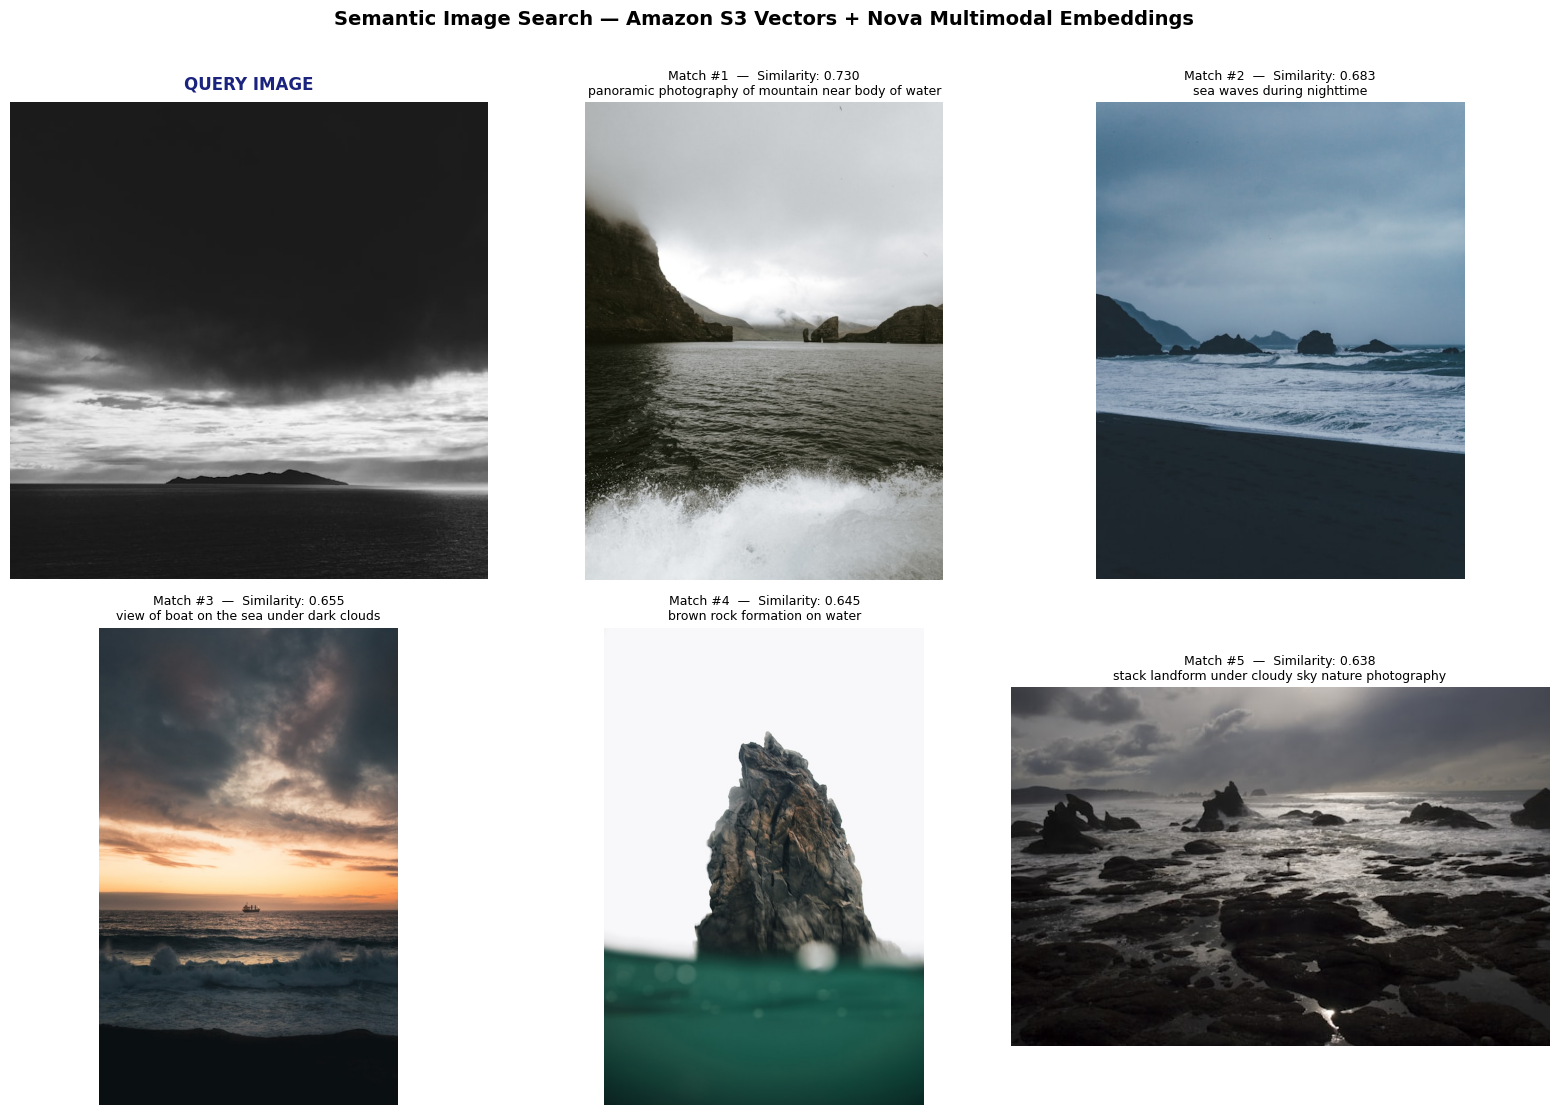


Query time  : 636.4 ms
Index size  : 1000 photos
Saved to    : search_results.png


In [29]:
def load_img(url: str, size: int = 600) -> Image.Image:
    if "unsplash.com" in url and "?" not in url:
        url = f"{url}?w={size}&q=80&fit=max"
    try:
        resp = requests.get(url, timeout=20)
        return Image.open(io.BytesIO(resp.content)).convert("RGB")
    except Exception:
        # Return a grey placeholder if image can't be loaded
        return Image.new("RGB", (size, size), color=(200, 200, 200))


# 2-row × 3-column grid
# ┌──────────┬──────────┬──────────┐
# │  QUERY   │ Match #1 │ Match #2 │
# ├──────────┼──────────┼──────────┤
# │ Match #3 │ Match #4 │ Match #5 │
# └──────────┴──────────┴──────────┘

fig, axes = plt.subplots(2, 3, figsize=(16, 11))
fig.suptitle(
    "Semantic Image Search — Amazon S3 Vectors + Nova Multimodal Embeddings",
    fontsize=14, fontweight="bold", y=1.01,
)

# --- Query image (top-left) -------------------------------------------------
ax_q = axes[0, 0]
ax_q.imshow(load_img(query_row["photo_image_url"]))
ax_q.set_title("QUERY IMAGE", fontsize=12, fontweight="bold",
               color="#1a237e", pad=10)
ax_q.axis("off")
for spine in ax_q.spines.values():       # draw a coloured border
    spine.set_visible(True)
    spine.set_edgecolor("#1a237e")
    spine.set_linewidth(5)

# --- 5 result images --------------------------------------------------------
result_positions = [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]

for idx, (row_i, col_i) in enumerate(result_positions):
    ax = axes[row_i, col_i]
    if idx >= len(results):
        ax.axis("off")
        continue

    res  = results[idx]
    url  = res["metadata"]["url"]
    dist = res.get("distance", float("nan"))
    sim  = 1.0 - dist
    desc = res["metadata"].get("description", "")
    phot = res["metadata"].get("photographer", "")

    ax.imshow(load_img(url))
    label = (
        f"Match #{idx+1}  —  Similarity: {sim:.3f}\n"
        + (desc[:55] + ("…" if len(desc) > 55 else "") if desc else phot)
    )
    ax.set_title(label, fontsize=9, pad=6)
    ax.axis("off")

plt.tight_layout()
plt.savefig("search_results.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nQuery time  : {elapsed_ms:.1f} ms")
print(f"Index size  : {len(vectors)} photos")
print(f"Saved to    : search_results.png")


---
## Optional — Cleanup

Run the cell below to delete the index and bucket after the demo.


In [ ]:
# Un-comment to delete the S3 Vectors resources after the demo

# print(f"Deleting index '{INDEX_NAME}'...")
# s3vectors_client.delete_index(
#     vectorBucketName=VECTOR_BUCKET_NAME,
#     indexName=INDEX_NAME,
# )
# print("  ✓ Index deleted")
#
# print(f"Deleting bucket '{VECTOR_BUCKET_NAME}'...")
# s3vectors_client.delete_vector_bucket(vectorBucketName=VECTOR_BUCKET_NAME)
# print("  ✓ Bucket deleted")
#
# print("Cleanup complete ✓")
